# Lab2

1. STAR and SLURM
2. ResQC
3. RESM and Salmon

## STAR (Spliced Transcripts Alignment to a Reference) 
- In RNA-seq, reads come from non-contiguous locations in the genome (due to splicing) . An aligner must be aware of this.
- Fast as expense of being memory intensive
- Therefore, the computation needs to be done on server: If on school server you need to use SLURM

## RSeQC (W/ .BAM)
- mRNA is an unstable molecule. It is important to check if your sample has been degreaded before analysis
- REsQC is a python package 
  - tin.py
  - geneBody_coverage.py

## Salmon and RSEM(from FSATQ to count)
- Output of Salmon: ENSEMBLE ID of transcipt and you need to convert with BioMart for just one 
- RESM: start from .bam but slow 

# Lab 3

1. PAC and H-clustering
2. Batch Removal
3. DESeq2
4. KMeans
5. DAVID
6. GSEA

## PCA

In [2]:
# Use rpy2 to load the R dataset 'decathlon2' from the 'factoextra' package
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [3]:

%%R
library(factoextra)
data(decathlon2)
head(decathlon2)


          X100m Long.jump Shot.put High.jump X400m X110m.hurdle Discus
SEBRLE    11.04      7.58    14.83      2.07 49.81        14.69  43.75
CLAY      10.76      7.40    14.26      1.86 49.37        14.05  50.72
BERNARD   11.02      7.23    14.25      1.92 48.93        14.99  40.87
YURKOV    11.34      7.09    15.19      2.10 50.42        15.31  46.26
ZSIVOCZKY 11.13      7.30    13.48      2.01 48.62        14.17  45.67
McMULLEN  10.83      7.31    13.76      2.13 49.91        14.38  44.41
          Pole.vault Javeline X1500m Rank Points Competition
SEBRLE          5.02    63.19  291.7    1   8217    Decastar
CLAY            4.92    60.15  301.5    2   8122    Decastar
BERNARD         5.32    62.77  280.1    4   8067    Decastar
YURKOV          4.72    63.44  276.4    5   8036    Decastar
ZSIVOCZKY       4.42    55.37  268.0    7   8004    Decastar
McMULLEN        4.42    56.37  285.1    8   7995    Decastar


Loading required package: ggplot2
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa
In addition: Warning messages:
1: package ‘factoextra’ was built under R version 4.4.3 
2: package ‘ggplot2’ was built under R version 4.4.3 


In [4]:

import pandas as pd
%R -o decathlon2
print(type(decathlon2))
decathlon2.head()

<class 'pandas.core.frame.DataFrame'>


,X100m,Long.jump,Shot.put,High.jump,X400m,X110m.hurdle,Discus,Pole.vault,Javeline,X1500m,Rank,Points,Competition
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,Decastar
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,Decastar
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,Decastar
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,Decastar
ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.0,7,8004,Decastar


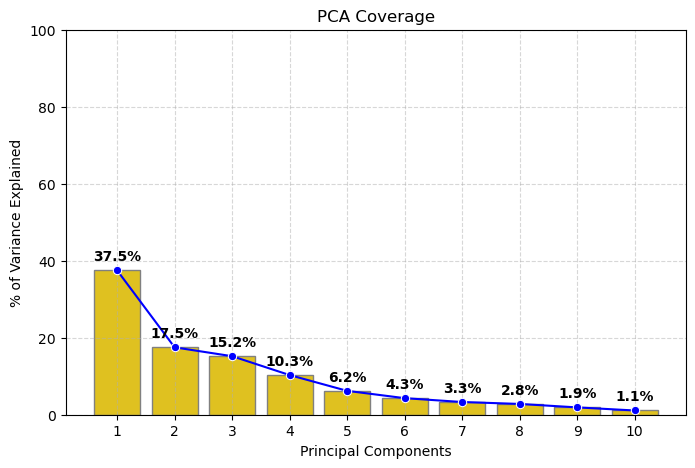

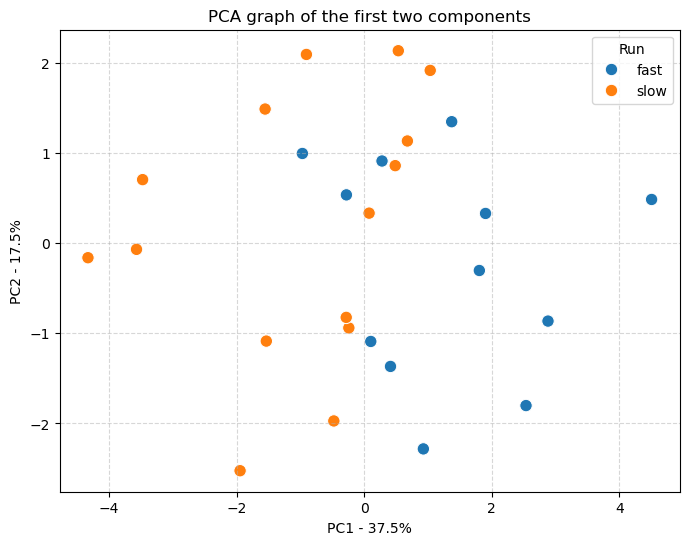

/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_74624/4157958039.py:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Run")


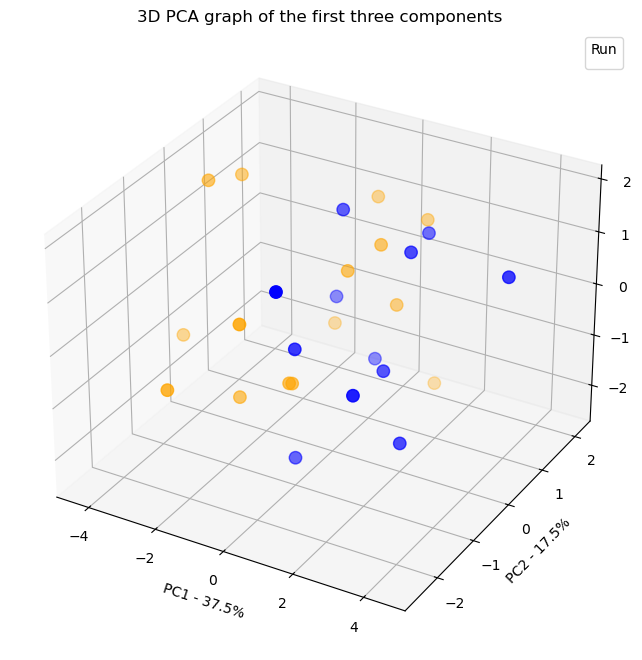

In [ ]:
# %% [markdown]
# ## PCA
# - Finds the best linear combinations of the variables.
# - "Best" means the direction that describes the largest variance.
# - Can produce lower-dimensional summaries of the data.
# - Useful for visualization, among other things.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# %%
# ## PCA Analysis Example
# The decathlon dataset equivalent is available from seaborn or manually loaded
# We'll simulate it using the R version structure for demonstration.

# You can install datasets if needed: pip install pydataset
# Active individuals (1:23) and active variables (1:10)
decathlon2_active = decathlon2.iloc[:27, :10]
decathlon2_active.head()

# %%
# Perform PCA with scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(decathlon2_active)

pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Calculate explained variance ratio (%)
pca_var_per = np.round(pca.explained_variance_ratio_ * 100, 1)

# %%
# Plot variance explained (equivalent to fviz_eig)
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(1, len(pca_var_per)+1), y=pca_var_per, color="gold", edgecolor="gray")
sns.lineplot(x=np.arange(0, len(pca_var_per)), y=pca_var_per, marker="o", color="blue") # 清楚为什么这里的x要从0开始而上面从1开始

# for i, val in enumerate(pca_var_per):
#     plt.text(i, val + 1.0, f"{val}%", ha='center', va='bottom', 
#              fontsize=10, color='black', fontweight='bold')


for container in plt.gca().containers:
    # 使用 ax.bar_label() 自动添加标签
    plt.bar_label(container, 
                 # 设置标签的格式，例如保留一位小数
                 fmt='%.1f%%', 
                 # 调整标签与条形顶部的间距
                 padding=5, 
                 fontsize=10, 
                 color='black', 
                 fontweight='bold',
                 label_type='edge')

plt.title("PCA Coverage")
plt.xlabel("Principal Components")
plt.ylabel("% of Variance Explained")
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# %%
# Prepare data for scatter plot (first two PCs)
pca_df = pd.DataFrame({
    'Sample': decathlon2_active.index,
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'X100m': decathlon2_active['X100m']
})

# Define color groups (fast/slow)
pca_df['Run'] = np.where(pca_df['X100m'] < 11, 'slow', 'fast')

# %%
# Scatter plot of first two PCs
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Run', s=80)
plt.title("PCA graph of the first two components")
plt.xlabel(f"PC1 - {pca_var_per[0]}%")
plt.ylabel(f"PC2 - {pca_var_per[1]}%")
plt.legend(title="Run")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 3D Scatter plot of first three PCs
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], 
                     c=np.where(pca_df['Run'] == 'fast', 'blue', 'orange'), s=80)
ax.set_title("3D PCA graph of the first three components")
ax.set_xlabel(f"PC1 - {pca_var_per[0]}%")
ax.set_ylabel(f"PC2 - {pca_var_per[1]}%")
ax.set_zlabel(f"PC3 - {pca_var_per[2]}%")
plt.show()

# %%
# ## Python Aside: PCA object
# In Python, PCA results are stored in an object (similar to R list).
# You can access individual elements like:
# - pca.components_ : loadings (eigenvectors)
# - pca.explained_variance_ : eigenvalues
# - pca.explained_variance_ratio_ : variance ratio
# - pca.mean_ : mean of features
# - pca.singular_values_ : singular values